# Optimizations using Krotov's method for quantum control

```2026/05/05```

1. Review theory for Krotov and write it here;
2. Follow pseudocode;
3. Compare to ```krotov``` package.


Let's start the proccess of optimization for the Morse-soft-Coulomb (MsC) potential.

Firstly, we need to define spectral values (energies, interaction matrix,...)

In [1]:
from emerald.quantum.msc_unperturbed import MsC_hamiltonian, MsC_eigstates
from emerald.potentials.msc_potential import MsC_return_points, MsC_potential

import numpy as np

# We will start with a global α parameter of 1 and energy of -0.5
alpha = 1
E0 = -0.5

# We define a position grid to calculate the Hamiltonian.

rm, rM = MsC_return_points(alpha, E0)
print(f"Return points: rm = {rm:.3f}, rM = {rM:.3f}")

# The position grid must acomodate the region where the wavefunction is non-negligible, 
# so we will use a grid that goes from below rm to higher than rM.

r_min = -3.5#rm*5
r_max = 1000#rM*20
print(f"Position grid: r_min = {r_min:.3f}, r_max = {r_max:.3f}")

# Let's check the potential at the boundaries of the grid.
V_r_min = MsC_potential(alpha, r_min)
V_r_max = MsC_potential(alpha, r_max)
print(f"Potential at r_min: V({r_min:.3f}) = {V_r_min:.3f}")
print(f"Potential at r_max: V({r_max:.3f}) = {V_r_max:.3f}")

# Defining the position grid.
N_points = 5000
r_grid = np.linspace(r_min, r_max, N_points)
print(f"dr = {r_grid[1] - r_grid[0]:.3f}")

# Now we can calculate the Hamiltonian matrix on this grid.
H, r_grid = MsC_hamiltonian(alpha, r_grid)

print(f"Hamiltonian matrix shape: {H.shape}")

# Calculate the eigenstates of the Hamiltonian
# truncating the spectrum to the lowest 500 states

base_size = 500
energies, eigstates = MsC_eigstates(H, r_grid, base_size)

print(f"Calculated {len(energies)} eigenstates.")
print(f"Lowest energy eigenvalues: {energies[0]:.3f}, {energies[1]:.3f}, {energies[2]:.3f}")
print(f"Number of bound states (E < 0): {np.sum(energies < 0)}")

Return points: rm = -0.756, rM = 1.732
Position grid: r_min = -3.500, r_max = 1000.000
Potential at r_min: V(-3.500) = 117.379
Potential at r_max: V(1000.000) = -0.001
dr = 0.201
Hamiltonian matrix shape: (5001, 5001)
Calculated 500 eigenstates.
Lowest energy eigenvalues: -0.556, -0.159, -0.067
Number of bound states (E < 0): 28


Now let's calculate the interaction matrix. The operator $\hat R$ can be represented in matrix form in the energy representation:
$$
    \Xi_{nm} = \braket{\varphi_n|\hat R|\varphi_m},
$$
where $\{\ket{\varphi_n}\}$ is the basis of energy (eigenvector of $H_0$)

In [2]:
from emerald.quantum.coupling_utils import interaction_matrix

Xi_vecs, Xi_vals, Xi_conjT = interaction_matrix(r_grid, eigstates)

print(f"Interaction matrix shape: {Xi_vecs.shape}")
print(f"Lowest interaction eigenvalues: {Xi_vals[0]:.3f}, {Xi_vals[1]:.3f}, {Xi_vals[2]:.3f}")

Interaction matrix shape: (500, 500)
Lowest interaction eigenvalues: -0.126, 1.396, 3.142


Now it is convenient to define the time array and pre calculate a few things:

In [3]:
# Single step evolution functions using the split-operator method
# U(δ) = e^-iH₀δ/2 · V · e^-iεΞδ · V† · e^-iH₀δ/2
# U†(δ) = e^iH₀δ/2 · V · e^iεΞδ · V† · e^iH₀δ/2
#
# Optimizations:
#   - Precompute exp_H0 once (outside the loop)
#   - Use Xi_conjT (conjugate transpose) instead of np.linalg.inv
#   - JIT-compile with numba

T = 100.0  # Total duration
delta_t = 0.05  # Time step
time_grid = np.arange(0, T + delta_t, delta_t)
N_T = len(time_grid)
print(f"Time grid: {N_T} points, dt = {delta_t:.3f}")

# Precompute the free-evolution phase factors (same for all steps)
exp_H0_fwd = np.exp(-1j * energies * delta_t / 2)
exp_H0_bwd = np.exp( 1j * energies * delta_t / 2)

Time grid: 2001 points, dt = 0.050


Finally we define the initial and target states: 

In [6]:
psi_0 = np.zeros(base_size, dtype=complex)
psi_0[0] = 1.0  # Start in the ground state

psi_target = np.zeros(base_size, dtype=complex)
psi_target[1] = 1.0  # Target the first excited state

exc1 = np.zeros(base_size, dtype=complex)
exc1[1] = 1.0  # First excited state

exc2 = np.zeros(base_size, dtype=complex)
exc2[2] = 1.0  # Second excited state

initial_guess_field = np.ones(N_T) * 0.01  # Initial guess for the control field (constant)

In [7]:
from emerald.quantum.krotov import KrotovOptimizer
optimizer = KrotovOptimizer(
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid,
    psi_0=psi_0, psi_target=psi_target,
    initial_field=initial_guess_field,
    lambda_a=50, t_on=10, t_off=10,
    max_iterations=300,
    JT_threshold=5e-3,      # stops early when converged
    store_histories=False,  # set True to keep all iterations' data
)
result = optimizer.run()  # verbose=True by default
print(result)             # KrotovResult(converged, iterations=142, best_JT=1.23e-05, ...)
optimized_field = result.optimized_field

iter.           J_T  |<psi|tgt>|     delta J_T    secs
-------------------------------------------------------
    0  9.997337e-01    0.016319           n/a     0.0
    1  9.994798e-01    0.022808    -2.539e-04     4.9
    2  9.989180e-01    0.032894    -5.618e-04     5.1
    3  9.977222e-01    0.047727    -1.196e-03     5.3
    4  9.952028e-01    0.069262    -2.519e-03     4.9
    5  9.899263e-01    0.100368    -5.276e-03     5.1
    6  9.789836e-01    0.144970    -1.094e-02     4.9
    7  9.567257e-01    0.208025    -2.226e-02     5.1
    8  9.131518e-01    0.294700    -4.357e-02     5.0
    9  8.339545e-01    0.407487    -7.920e-02     5.1
   10  7.084951e-01    0.539912    -1.255e-01     5.1
   11  5.493503e-01    0.671304    -1.591e-01     5.4
   12  3.969144e-01    0.776586    -1.524e-01     5.2
   13  2.844547e-01    0.845899    -1.125e-01     5.1
   14  2.150450e-01    0.885977    -6.941e-02     5.2
   15  1.759969e-01    0.907746    -3.905e-02     5.5
   16  1.546399e-01    0.

KeyboardInterrupt: 

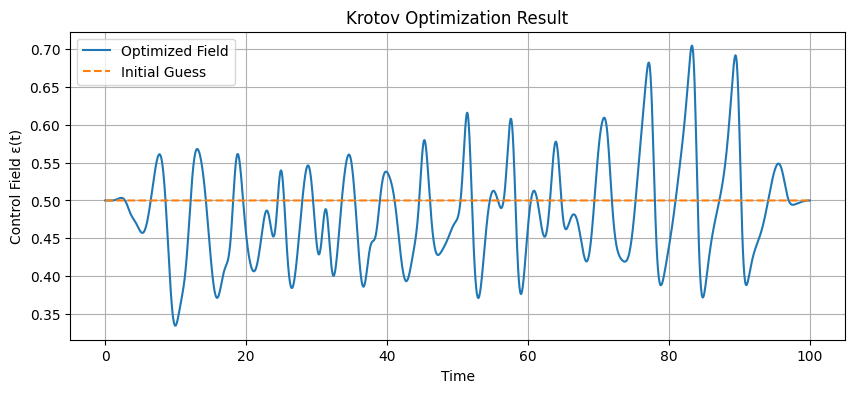

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(time_grid, optimized_field, label='Optimized Field')
plt.plot(time_grid, initial_guess_field, label='Initial Guess', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Control Field ε(t)')
plt.title('Krotov Optimization Result')
plt.legend()
plt.grid()
plt.show()

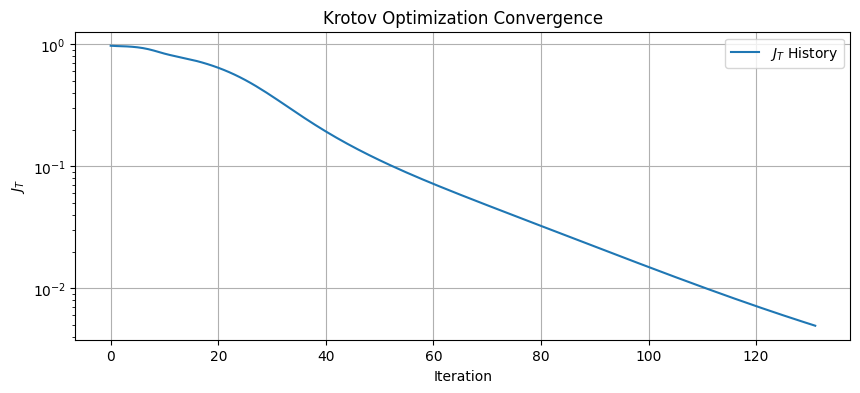

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(result.JT_history, label='$J_T$ History')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('$J_T$')
plt.title('Krotov Optimization Convergence')
plt.legend()
plt.grid()
plt.show()

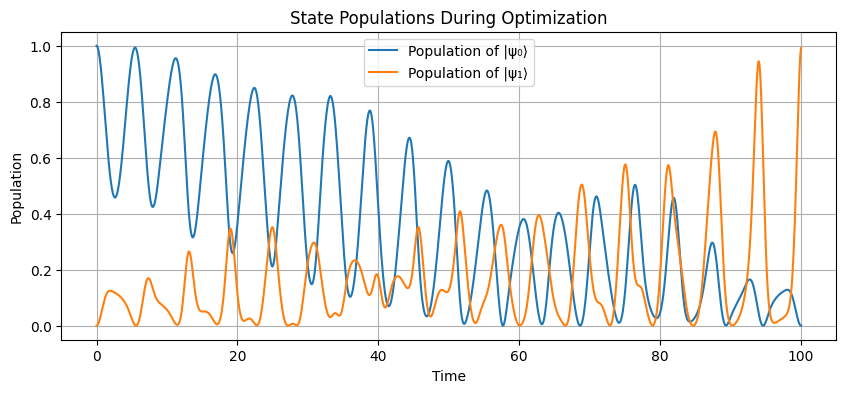

In [8]:
# Propagate the initial state with the optimized field to check the final state
phi_history, final_state = optimizer._forward_propagate(optimized_field)

plt.figure(figsize=(10, 4))
plt.plot(time_grid, np.abs(phi_history[0, :])**2, label='Population of |ψ₀⟩')
plt.plot(time_grid, np.abs(phi_history[1, :])**2, label='Population of |ψ₁⟩')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('State Populations During Optimization')
plt.legend()
plt.grid()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_179345/3738955196.py:10: SyntaxWarning: invalid escape sequence '\P'
  ax.set_ylabel('$|\Psi(r, t)|^2$')


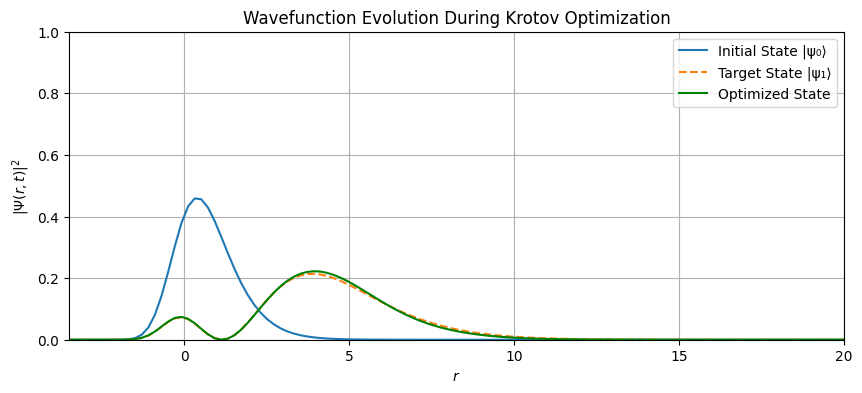

In [9]:
# Animate wavefunction evolution (requires matplotlib animation support)
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(10, 4))
psi_0_pos = eigstates @ psi_0  # Initial state in position space
psi_target_pos = eigstates @ psi_target  # Target state in position space
line_0 = ax.plot(r_grid, np.abs(psi_0_pos)**2, label='Initial State |ψ₀⟩')
line_target, = ax.plot(r_grid, np.abs(psi_target_pos)**2, label='Target State |ψ₁⟩', linestyle='--')
line, = ax.plot(r_grid, np.abs( eigstates @ phi_history[:, 0])**2, label='Optimized State', color='green')
ax.set_xlabel('$r$')
ax.set_ylabel('$|\Psi(r, t)|^2$')
ax.set_title('Wavefunction Evolution During Krotov Optimization')
ax.legend()
plt.xlim(-3.5, 20)
plt.ylim(0, 1)
ax.grid()

def update(frame):
    psi_t = eigstates @ phi_history[:, frame]
    line.set_ydata(np.abs(psi_t)**2)
    return line,

frames = np.arange(len(time_grid))[::5]  # Update every 5 time steps
ani = animation.FuncAnimation(fig, update, frames=frames, blit=True)
ani.save('krotov_optimization_evolution.mp4', writer='ffmpeg', fps=30)
plt.show()

In [10]:
# Let's try a sinusoidal initial guess field to see if it converges faster.
omega01 = energies[1] - energies[0]
initial_guess_field2 = 0.5 *np.sin(omega01 * time_grid)

In [11]:
optimizer2 = KrotovOptimizer(
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid,
    psi_0=psi_0, psi_target=psi_target,
    initial_field=initial_guess_field2,
    lambda_a=50, t_on=10, t_off=10,
    max_iterations=300,
    JT_threshold=5e-3,      # stops early when converged
    store_histories=False,  # set True to keep all iterations' data
)
result2 = optimizer2.run()  # verbose=True by default
print(result2)             # KrotovResult(converged, iterations=..., best_JT=..., ...)
optimized_field2 = result2.optimized_field

iter.           J_T  |<psi|tgt>|     delta J_T    secs
-------------------------------------------------------
    0  5.569157e-01    0.665646           n/a     0.0
    1  7.964508e-01    0.451164    +2.395e-01     4.5
    2  6.914351e-01    0.555486    -1.050e-01     3.0
    3  5.484878e-01    0.671947    -1.429e-01     3.2
    4  3.050567e-01    0.833633    -2.434e-01     3.0
    5  2.913585e-01    0.841808    -1.370e-02     2.9
    6  2.133652e-01    0.886924    -7.799e-02     3.1
    7  2.138102e-01    0.886673    +4.450e-04     3.8
    8  1.903973e-01    0.899779    -2.341e-02     3.7
    9  1.845287e-01    0.903035    -5.869e-03     3.3
   10  1.769907e-01    0.907199    -7.538e-03     3.3
   11  1.679745e-01    0.912154    -9.016e-03     3.2
   12  1.663546e-01    0.913042    -1.620e-03     3.5
   13  1.565329e-01    0.918405    -9.822e-03     3.2
   14  1.574548e-01    0.917903    +9.219e-04     3.5
   15  1.479084e-01    0.923088    -9.546e-03     3.6
   16  1.500923e-01    0.

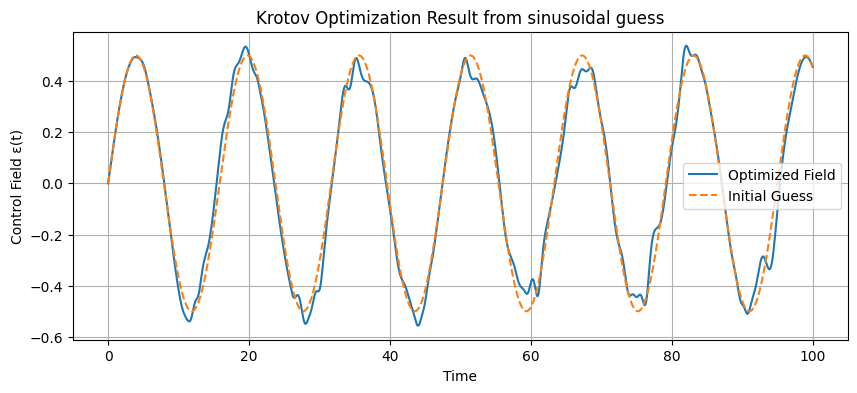

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, optimized_field2, label='Optimized Field')
plt.plot(time_grid, initial_guess_field2, label='Initial Guess', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Control Field ε(t)')
plt.title('Krotov Optimization Result from sinusoidal guess')
plt.legend()
plt.grid()
plt.show()

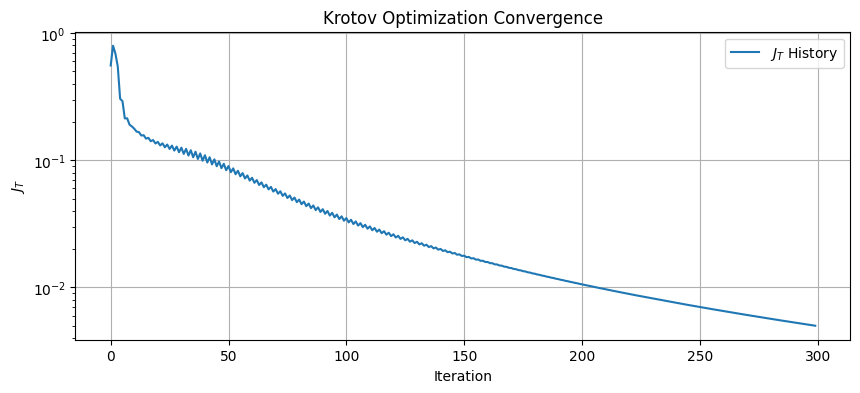

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(result2.JT_history, label='$J_T$ History')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('$J_T$')
plt.title('Krotov Optimization Convergence')
plt.legend()
plt.grid()
plt.show()

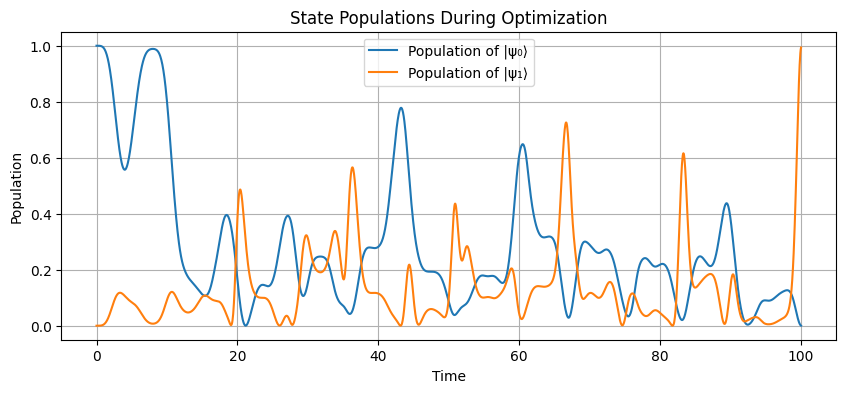

In [14]:
# Propagate the initial state with the optimized field to check the final state
phi_history2, final_state2 = optimizer2._forward_propagate(optimized_field2)

plt.figure(figsize=(10, 4))
plt.plot(time_grid, np.abs(phi_history2[0, :])**2, label='Population of |ψ₀⟩')
plt.plot(time_grid, np.abs(phi_history2[1, :])**2, label='Population of |ψ₁⟩')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('State Populations During Optimization')
plt.legend()
plt.grid()
plt.show()

In [15]:
# Let's try a different initial guess
from emerald.utils import FieldParams, external_field_array

field_params = FieldParams(amplitude=0.5,
                           frequency=omega01,
                           envelope='linear',
                           rampup_time=10,
                           rampdown_time=10,
                           operation_time=T,
                           form='cos')
initial_guess_field3 = external_field_array(time_grid, field_params)


optimizer3 = KrotovOptimizer(
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid,
    psi_0=psi_0, psi_target=psi_target,
    initial_field=initial_guess_field3,
    lambda_a=50, t_on=10, t_off=10,
    max_iterations=300,
    JT_threshold=5e-3,      # stops early when converged
    store_histories=False,  # set True to keep all iterations' data
)
result3 = optimizer3.run()  # verbose=True by default
print(result3)             # KrotovResult(converged, iterations=..., best_JT=..., ...)
optimized_field3 = result3.optimized_field

iter.           J_T  |<psi|tgt>|     delta J_T    secs
-------------------------------------------------------
    0  9.442571e-01    0.236099           n/a     0.0
    1  9.971457e-01    0.053425    +5.289e-02     2.9
    2  9.912501e-01    0.093541    -5.896e-03     3.1
    3  9.661370e-01    0.184019    -2.511e-02     3.0
    4  8.777103e-01    0.349700    -8.843e-02     2.9
    5  6.517661e-01    0.590113    -2.259e-01     3.3
    6  3.877189e-01    0.782484    -2.640e-01     2.8
    7  2.490293e-01    0.866586    -1.387e-01     3.0
    8  1.822621e-01    0.904289    -6.677e-02     3.1
    9  1.393673e-01    0.927703    -4.289e-02     3.1
   10  1.073974e-01    0.944776    -3.197e-02     3.1
   11  8.211215e-02    0.958065    -2.529e-02     2.9
   12  6.348274e-02    0.967738    -1.863e-02     3.0
   13  4.959042e-02    0.974890    -1.389e-02     2.9
   14  3.996603e-02    0.979813    -9.624e-03     2.9
   15  3.296335e-02    0.983380    -7.003e-03     3.0
   16  2.818887e-02    0.

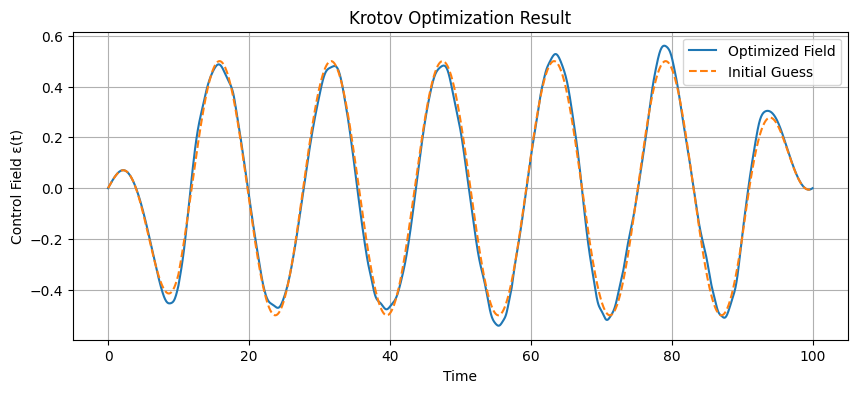

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, optimized_field3, label='Optimized Field')
plt.plot(time_grid, initial_guess_field3, label='Initial Guess', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Control Field ε(t)')
plt.title('Krotov Optimization Result')
plt.legend()
plt.grid()
plt.show()

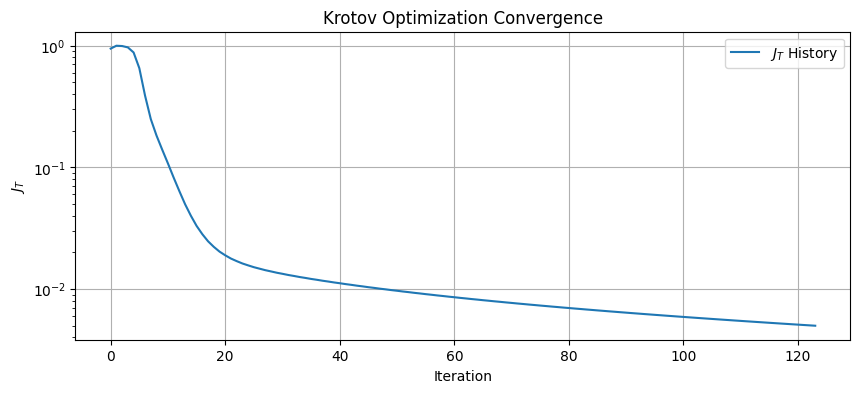

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(result3.JT_history, label='$J_T$ History')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('$J_T$')
plt.title('Krotov Optimization Convergence')
plt.legend()
plt.grid()
plt.show()

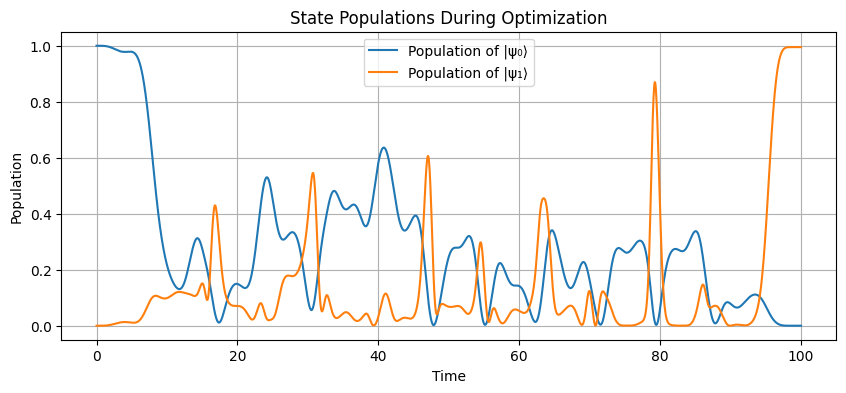

In [18]:
# Propagate the initial state with the optimized field to check the final state
phi_history3, final_state3 = optimizer3._forward_propagate(optimized_field3)

plt.figure(figsize=(10, 4))
plt.plot(time_grid, np.abs(phi_history3[0, :])**2, label='Population of |ψ₀⟩')
plt.plot(time_grid, np.abs(phi_history3[1, :])**2, label='Population of |ψ₁⟩')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('State Populations During Optimization')
plt.legend()
plt.grid()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_179345/4205152099.py:10: SyntaxWarning: invalid escape sequence '\P'
  ax.set_ylabel('$|\Psi(r, t)|^2$')


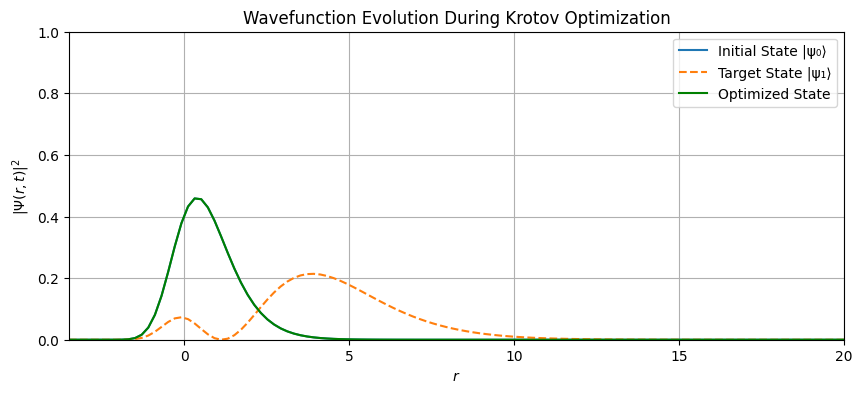

In [19]:
# Animate wavefunction evolution (requires matplotlib animation support)
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(10, 4))
psi_0_pos = eigstates @ psi_0  # Initial state in position space
psi_target_pos = eigstates @ psi_target  # Target state in position space
line_0 = ax.plot(r_grid, np.abs(psi_0_pos)**2, label='Initial State |ψ₀⟩')
line_target, = ax.plot(r_grid, np.abs(psi_target_pos)**2, label='Target State |ψ₁⟩', linestyle='--')
line, = ax.plot(r_grid, np.abs( eigstates @ phi_history3[:, 0])**2, label='Optimized State', color='green')
ax.set_xlabel('$r$')
ax.set_ylabel('$|\Psi(r, t)|^2$')
ax.set_title('Wavefunction Evolution During Krotov Optimization')
ax.legend()
plt.xlim(-3.5, 20)
plt.ylim(0, 1)
ax.grid()

def update(frame):
    psi_t = eigstates @ phi_history3[:, frame]
    line.set_ydata(np.abs(psi_t)**2)
    return line,

frames = np.arange(len(time_grid))[::5]  # Update every 5 time steps
ani = animation.FuncAnimation(fig, update, frames=frames, blit=True)
plt.show()
ani.save('krotov_optimization_evolution.mp4', writer='ffmpeg', fps=30)

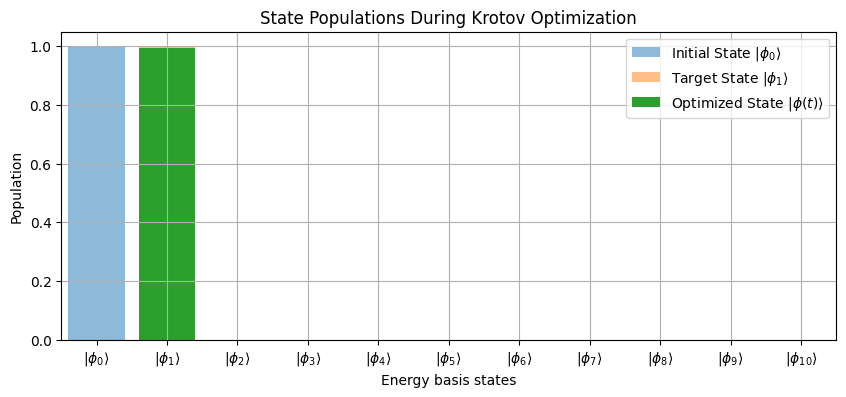

In [22]:
fig = plt.figure(figsize=(10, 4))

plt.bar(range(len(psi_0)), np.abs(psi_0)**2, label='Initial State $|\\phi_0\\rangle$', alpha=0.5)
plt.bar(range(len(psi_target)), np.abs(psi_target)**2, label='Target State $|\\phi_1\\rangle$', alpha=0.5)

bar_container = plt.bar(range(len(phi_history3[:, 0])),
                        np.abs(phi_history3[:, 0])**2,
                        label='Optimized State $|\\phi(t)\\rangle$')

bars = bar_container.patches

def update(frame):
    for i, b in enumerate(bars):
        b.set_height(np.abs(phi_history3[i, frame])**2)
    return bars

frames = np.arange(len(time_grid))[::5]

ani = animation.FuncAnimation(fig, update, frames=frames, blit=False)

plt.xlabel('Energy basis states')
plt.xticks(range(11), [rf'$|\phi_{{{i}}}\rangle$' for i in range(11)])
plt.ylabel('Population')
plt.title('State Populations During Krotov Optimization')
plt.legend()
plt.xlim(-0.5, 10.5)
plt.grid()

from matplotlib.animation import PillowWriter

ani.save('test.gif', writer=PillowWriter(fps=20))

# ani.save('krotov_population_evolution.mp4', writer='ffmpeg', fps=20)
plt.show()

In [21]:
print(animation.writers.list())

['pillow', 'ffmpeg', 'ffmpeg_file', 'imagemagick', 'imagemagick_file', 'html']


In [23]:
import qutip
import krotov

# H0 is diagonal in the energy eigenbasis — just wrap the diagonal matrix
H0_qobj = qutip.Qobj(np.diag(energies))

# R̂ in the energy eigenbasis: Ξ = V D V⁻¹ — build it once
R_matrix = Xi_vecs @ np.diag(Xi_vals) @ Xi_conjT
H1_qobj = qutip.Qobj(R_matrix)

# Guess field: can be a callable or your precomputed array.
# The callable form lets mesolve evaluate it at arbitrary t.
def guess_control(t, args):
    return float(np.interp(t, time_grid, initial_guess_field3))

H = [H0_qobj, [H1_qobj, guess_control]]

In [34]:
from emerald.quantum.krotov import single_step_evolution, single_step_inverse_evolution

psi_0_qobj      = qutip.Qobj(psi_0)
psi_target_qobj = qutip.Qobj(psi_target)

objectives = [
    krotov.Objective(initial_state=psi_0_qobj, target=psi_target_qobj, H=H)
]

def split_op_propagator(H, state, dt, c_ops=None, backwards=False, initialize=False):
    """
    Wraps your split-operator stepper for the krotov package.
    H here is the assembled Hamiltonian at this time step as a Qobj.
    The package calls it as H = H0 + eps*H1, but we bypass that and use
    our pre-factored form for efficiency.
    """
    eps = float(np.real(H[1][1]))   # scalar control value baked in by krotov
    psi = state.full().ravel()       # Qobj -> numpy 1D array

    if not backwards:
        result = single_step_evolution(psi, eps, exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)
    else:
        result = single_step_inverse_evolution(psi, eps, exp_H0_bwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)

    return qutip.Qobj(result)

In [35]:
from emerald.quantum.krotov import S_l
def S_qutip(t):
    return float(S_l(t, T, 10, 10))
krotov_lambda_a = 50
pulse_options = {
    H[1][1]: dict(lambda_a=krotov_lambda_a, update_shape=S_qutip)
}

# cap the total number of iterations and set convergence criteria
opt_result = krotov.optimize_pulses(
    objectives,
    pulse_options=pulse_options,
    tlist=time_grid,
    iter_stop=200,
    propagator=split_op_propagator,
    chi_constructor=krotov.functionals.chis_ss,
    info_hook=krotov.info_hooks.print_table(J_T=krotov.functionals.J_T_ss),
    check_convergence=krotov.convergence.Or(
        krotov.convergence.value_below('5e-3', name='J_T'),
        krotov.convergence.check_monotonic_error,
    ),
    store_all_pulses=True,
)

iter.      J_T    ∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     9.44e-01    0.00e+00   9.44e-01        n/a        n/a     1
1     8.21e-01    4.40e-02   8.65e-01  -1.23e-01  -7.92e-02     8
2     5.95e-01    8.93e-02   6.84e-01  -2.26e-01  -1.37e-01     8
3     4.21e-01    7.79e-02   4.99e-01  -1.74e-01  -9.61e-02     8
4     3.49e-01    3.39e-02   3.83e-01  -7.21e-02  -3.82e-02     8
5     3.12e-01    1.75e-02   3.29e-01  -3.74e-02  -2.00e-02     8
6     2.80e-01    1.46e-02   2.95e-01  -3.12e-02  -1.66e-02     8
7     2.49e-01    1.47e-02   2.64e-01  -3.11e-02  -1.64e-02     8
8     2.18e-01    1.49e-02   2.33e-01  -3.11e-02  -1.62e-02     8
9     1.88e-01    1.44e-02   2.03e-01  -2.98e-02  -1.54e-02     8
10    1.61e-01    1.33e-02   1.74e-01  -2.74e-02  -1.41e-02     8
11    1.37e-01    1.19e-02   1.49e-01  -2.43e-02  -1.25e-02     8
12    1.16e-01    1.03e-02   1.26e-01  -2.10e-02  -1.08e-02     8
13    9.78e-02    8.70e-03   1.06e-01  -1.78e-02  -9.15e-03     8
14    8.28

In [36]:
opt_result

Krotov Optimization Result
--------------------------
- Started at 2026-05-05 14:06:06
- Number of objectives: 1
- Number of iterations: 57
- Reason for termination: Reached convergence: J_T < 5e-3
- Ended at 2026-05-05 14:14:01 (0:07:55)

In [37]:
krotov_field = opt_result.optimized_controls[0]

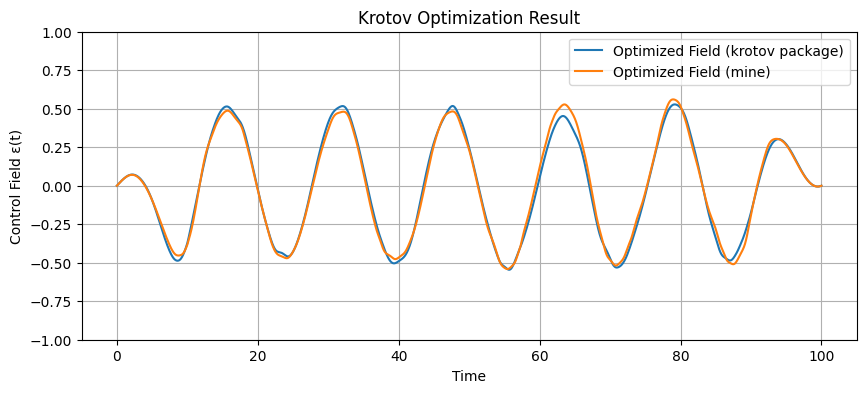

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, krotov_field, label='Optimized Field (krotov package)')
plt.plot(time_grid, optimized_field3, label='Optimized Field (mine)')
# plt.plot(time_grid, initial_guess_field3, label='Initial Guess', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Control Field ε(t)') 
plt.title('Krotov Optimization Result')
plt.legend()
plt.ylim(-1, 1)
plt.grid()
plt.show()

In [42]:
def guess_control_constant(t, args):
    return 0.5

H2 = [H0_qobj, [H1_qobj, guess_control_constant]]
objectives2 = [
    krotov.Objective(initial_state=psi_0_qobj, target=psi_target_qobj, H=H2)
]
pulse_options2 = {
    H2[1][1]: dict(lambda_a=krotov_lambda_a, update_shape=S_qutip)
}

# cap the total number of iterations and set convergence criteria
opt_result2 = krotov.optimize_pulses(
    objectives2,
    pulse_options=pulse_options2,
    tlist=time_grid,
    iter_stop=200,
    propagator=split_op_propagator,
    chi_constructor=krotov.functionals.chis_ss,
    info_hook=krotov.info_hooks.print_table(J_T=krotov.functionals.J_T_ss),
    check_convergence=krotov.convergence.Or(
        krotov.convergence.value_below('5e-3', name='J_T'),
        krotov.convergence.check_monotonic_error,
    ),
    store_all_pulses=True,
)

iter.      J_T    ∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     9.72e-01    0.00e+00   9.72e-01        n/a        n/a     1
1     9.59e-01    5.90e-03   9.65e-01  -1.31e-02  -7.16e-03     8
2     9.41e-01    8.12e-03   9.49e-01  -1.80e-02  -9.91e-03     8
3     9.18e-01    1.01e-02   9.28e-01  -2.25e-02  -1.24e-02     8
4     8.93e-01    1.16e-02   9.04e-01  -2.57e-02  -1.42e-02     7
5     8.65e-01    1.24e-02   8.77e-01  -2.75e-02  -1.51e-02     7
6     8.37e-01    1.25e-02   8.50e-01  -2.78e-02  -1.52e-02     7
7     8.11e-01    1.21e-02   8.23e-01  -2.67e-02  -1.46e-02     8
8     7.86e-01    1.14e-02   7.97e-01  -2.49e-02  -1.35e-02     7
9     7.62e-01    1.09e-02   7.73e-01  -2.33e-02  -1.25e-02     8
10    7.40e-01    1.05e-02   7.51e-01  -2.22e-02  -1.17e-02     7
11    7.18e-01    1.04e-02   7.29e-01  -2.17e-02  -1.13e-02     7
12    6.97e-01    1.06e-02   7.07e-01  -2.18e-02  -1.12e-02     7
13    6.74e-01    1.09e-02   6.85e-01  -2.23e-02  -1.14e-02     7
14    6.51

In [43]:
krotov_field2 = opt_result2.optimized_controls[0]

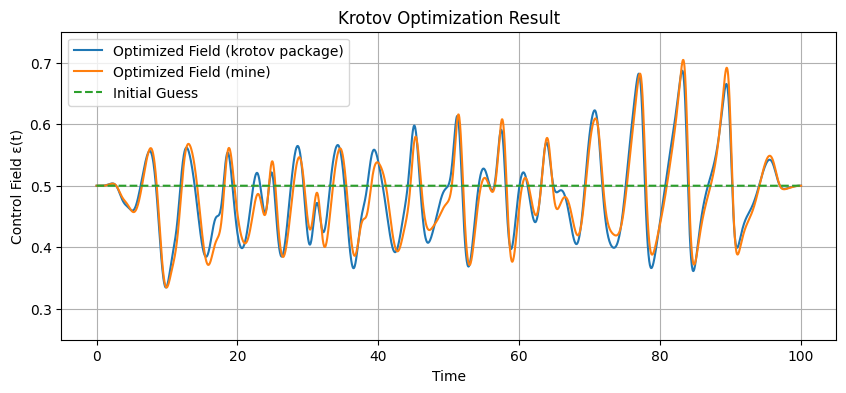

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(time_grid, krotov_field2, label='Optimized Field (krotov package)')
plt.plot(time_grid, optimized_field, label='Optimized Field (mine)')
plt.plot(time_grid, initial_guess_field, label='Initial Guess', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Control Field ε(t)') 
plt.title('Krotov Optimization Result')
plt.legend()
plt.ylim(0.25, 0.75)
plt.grid()
plt.show()

In [ ]:
from emerald.quantum.krotov import (
    KrotovOptimizer, KrotovMultiOptimizer, IonizationOptimizer,
    Objective,
)
# --- Single objective (ground → excited) ---
result_ss = KrotovOptimizer(
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid, psi_0=psi_0, psi_target=psi_target,
    initial_field=initial_guess_field,
    lambda_a=50, JT_threshold=5e-3, max_iterations=300,
).run()
# --- Multi-objective (ground → excited1 AND ground → excited2) ---
objectives = [
    Objective(psi_0=psi_0, psi_target=exc1, weight=0.5),
    Objective(psi_0=psi_0, psi_target=exc2, weight=0.5),
]
result_ms = KrotovMultiOptimizer(
    objectives=objectives,
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid, initial_field=initial_guess_field,
    lambda_a=50, JT_threshold=5e-3,
).run()
# --- Ionization (minimize bound population) ---
bound_mask = energies < 0
result_ion = IonizationOptimizer(
    psi_0=psi_0, bound_mask=bound_mask,
    energies=energies, Xi_vals=Xi_vals, Xi_vecs=Xi_vecs, Xi_conjT=Xi_conjT,
    time_grid=time_grid, initial_field=initial_guess_field,
    lambda_a=50, JT_threshold=0.01,
).run()

iter.           J_T  |<psi|tgt>|     delta J_T    secs
-------------------------------------------------------
    0  9.760039e-01    0.154907           n/a     0.0
    1  9.703317e-01    0.172245    -5.672e-03     5.2
    2  9.675850e-01    0.180042    -2.747e-03     5.1
    3  9.632141e-01    0.191796    -4.371e-03     3.9
    4  9.566378e-01    0.208236    -6.576e-03     6.2
    5  9.469715e-01    0.230279    -9.666e-03     4.8
    6  9.331303e-01    0.258592    -1.384e-02     3.9
    7  9.143527e-01    0.292656    -1.878e-02     2.9
    8  8.910219e-01    0.330118    -2.333e-02     3.2
    9  8.652540e-01    0.367078    -2.577e-02     3.7
   10  8.405967e-01    0.399253    -2.466e-02     3.6
   11  8.193580e-01    0.425020    -2.124e-02     3.4
   12  8.010611e-01    0.446026    -1.830e-02     3.9
   13  7.841111e-01    0.464638    -1.695e-02     3.5
   14  7.671989e-01    0.482495    -1.691e-02     5.3
   15  7.495653e-01    0.500435    -1.763e-02     5.2
   16  7.308509e-01    0.